Group Members: Abijeet Dhillon, Noor Fatima, Tam Nguyen

* Data Source: https://databank.worldbank.org/source/world-development-indicators#advancedDownloadOptions
* Describe the data:

# **Potential Question**

**Economic development and  Energy Resources**
* How does energy use per capita relate to GDP per capita — does energy use continue to increase as countries become wealthier, or does it level off?
* How does dependence on energy imports relate to economic growth — do countries that rely more heavily on imported energy show different growth patterns?
* Do countries with higher natural-resource rents have higher GDP per capita, or is resource dependence unrelated to economic development
* Do countries with increasing electricity access also experience higher GDP per capita growth?

**Urbanization and Energy use**
* How does urbanization correlate with CO2 emissions per capita — does it rise together or decouple in wealthier countries?
* How does urbanization relate to energy use per capita — is the relationship different between lower-income and wealthier countries?

**Economic Development and CO2**
* How does energy use per capita relate to CO2 emissions — do countries with higher renewable energy use show a different relationship?
* How does GDP per capita relate to CO2 emissions per capita — do emissions continue to increase at higher income levels or begin to level off?
* Does greater renewable energy consumption correspond to lower CO2 emissions — and is this relationship different in wealthier countries?

# **ML Question: Can energy, economic, infrastructure, urbanization, and environmental indicators in one year predict a country's GDP per capita in the following year?**




In [ ]:
# Import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data collection

##Import data into colaboratory.

In [ ]:
# Connect with GG Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the csv file
file_path = "/content/drive/MyDrive/Colab Notebooks/UoC/DATA601_Project/Data.xlsx"

df = pd.read_excel(file_path)

df.head()

,Country Name,Country Code,Series Name,Series Code,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,5.357403,13.826320,3.924984,21.390528,14.362441,0.426355,...,2.260314,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.266944,1.873193,NaN
1,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1929.723897,2155.353068,2191.504356,2565.022086,2848.586061,2757.052587,...,2958.785399,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,1964.452289,NaN
2,Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,1.132485,11.692303,1.677279,17.043896,11.055031,-3.213295,...,-0.300121,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,-0.975915,NaN
3,Afghanistan,AFG,"Energy imports, net (% of energy use)",EG.IMP.CONS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Energy intensity level of primary energy (MJ/$...,EG.EGY.PRIM.PP.KD,1.500000,1.540000,1.950000,2.270000,2.630000,3.250000,...,2.210000,2.270000,2.400000,2.370000,2.540000,2.940000,NaN,NaN,NaN,NaN


##Determine the types of data

In [ ]:
# Get information about the dataset
print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNumber of unique countries:")
print(df["Country Name"].nunique())

print("\nUnique countries:")
print(df["Country Name"].unique())

Dataset shape:
(5208, 24)

Data types:
Country Name      object
Country Code      object
Series Name       object
Series Code       object
2006 [YR2006]    float64
2007 [YR2007]    float64
2008 [YR2008]    float64
2009 [YR2009]    float64
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
2025 [YR2025]    float64
dtype: object

Number of unique countries:
217

Unique countries:
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzeg

## Data Cleaning/Reformating

In [ ]:
# Check for duplicated values
df.duplicated().sum()

np.int64(0)

###Remove unnecessary columns (Country code and Series Code)

In [ ]:
df = df.drop(columns=["Country Code", "Series Code"])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (5208, 22)


,Country Name,Series Name,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,GDP growth (annual %),5.357403,13.826320,3.924984,21.390528,14.362441,0.426355,12.752287,5.600745,...,2.260314,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.266944,1.873193,NaN
1,Afghanistan,"GDP per capita, PPP (constant 2021 internation...",1929.723897,2155.353068,2191.504356,2565.022086,2848.586061,2757.052587,2985.319145,3046.579931,...,2958.785399,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,1964.452289,NaN
2,Afghanistan,GDP per capita growth (annual %),1.132485,11.692303,1.677279,17.043896,11.055031,-3.213295,8.279369,2.052068,...,-0.300121,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,-0.975915,NaN
3,Afghanistan,"Energy imports, net (% of energy use)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Energy intensity level of primary energy (MJ/$...,1.500000,1.540000,1.950000,2.270000,2.630000,3.250000,2.600000,2.440000,...,2.210000,2.270000,2.400000,2.370000,2.540000,2.940000,NaN,NaN,NaN,NaN


###Reshape the data for easier analysis

In [ ]:
# Convert year to rows
df_long = df.melt(
    id_vars=["Country Name", "Series Name"],
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = (
    df_long["Year"]
    .str.extract(r"(\d{4})")[0]                        # 2011 [YR2011] -> 2011
    .astype(int)                                       # Convert to int for easier filter later
)

df_long.head()

,Country Name,Series Name,Year,Value
0,Afghanistan,GDP growth (annual %),2006,5.357403
1,Afghanistan,"GDP per capita, PPP (constant 2021 internation...",2006,1929.723897
2,Afghanistan,GDP per capita growth (annual %),2006,1.132485
3,Afghanistan,"Energy imports, net (% of energy use)",2006,NaN
4,Afghanistan,Energy intensity level of primary energy (MJ/$...,2006,1.500000


In [ ]:
# Convert indicators from rows to columns
df_reshape = df_long.pivot(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

df_reshape.columns.name = None                # Remove the extra label above the columns

df_reshape.head()

,Country Name,Year,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Electric power consumption (kWh per capita),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP growth (annual %),...,"Manufacturing, value added (% of GDP)",Population density (people per sq. km of land area),Population growth (annual %),Renewable energy consumption (% of total final energy consumption),Rural population (% of total population),Rural population growth (annual %),Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),Urban population growth (annual %)
0,Afghanistan,2006,33.5,0.055794,NaN,NaN,1.50,NaN,NaN,5.357403,...,16.385537,38.980258,4.092702,31.9,79.889547,3.587604,0.504174,NaN,20.110453,6.124807
1,Afghanistan,2007,38.4,0.079669,NaN,NaN,1.54,NaN,NaN,13.826320,...,17.747310,39.725023,1.892598,28.8,79.409342,1.289695,0.449501,NaN,20.590658,4.252381
2,Afghanistan,2008,42.4,0.147376,NaN,NaN,1.95,NaN,NaN,3.924984,...,17.839116,40.603195,2.186546,21.2,78.875852,1.512458,0.601666,NaN,21.124148,4.744478
3,Afghanistan,2009,48.3,0.224491,NaN,NaN,2.27,NaN,NaN,21.390528,...,13.149877,42.111067,3.646381,16.5,78.311452,2.928255,0.424658,NaN,21.688548,6.283131
4,Afghanistan,2010,42.7,0.278192,NaN,NaN,2.63,NaN,NaN,14.362441,...,12.522577,43.365207,2.934687,15.2,77.738520,2.200387,0.625333,NaN,22.261480,5.542043


In [ ]:
# Dataset information after reformating
print("Dataset shape:")
print(df_reshape.shape)

print("\nNumber of countries:")
print(df_reshape["Country Name"].nunique())

print("\nData types:")
print(df_reshape.dtypes)

Dataset shape:
(4340, 26)

Number of countries:
217

Data types:
Country Name                                                                   object
Year                                                                            int64
Access to electricity (% of population)                                       float64
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)    float64
Electric power consumption (kWh per capita)                                   float64
Energy imports, net (% of energy use)                                         float64
Energy intensity level of primary energy (MJ/$2021 PPP GDP)                   float64
Energy use (kg of oil equivalent per capita)                                  float64
Fossil fuel energy consumption (% of total)                                   float64
GDP growth (annual %)                                                         float64
GDP per capita growth (annual %)                                           

###Treating Missing Values

In [ ]:
# Check missing data by years
missing_data = df_reshape.isna()
missing_data["Year"] = df_reshape["Year"]

missing_by_year = missing_data.groupby("Year").sum()                    # Count missing values by year
missing_by_year["Total Missing"] = missing_by_year.sum(axis=1)          # Add total missing values for each year

number_indicators = len(df_reshape.columns) - 2                         # Number of indicators (not include Country Name and Year)
number_countries = df_reshape["Country Name"].nunique()                 # Number of countries
total_values = number_indicators * number_countries                     # Total values in one year

missing_by_year["Missing Percentage"] = (                               # Calculate percentage of missing values
    missing_by_year["Total Missing"] / total_values
) * 100

missing_by_year

,Country Name,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Electric power consumption (kWh per capita),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP growth (annual %),GDP per capita growth (annual %),...,Population growth (annual %),Renewable energy consumption (% of total final energy consumption),Rural population (% of total population),Rural population growth (annual %),Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),Urban population growth (annual %),Total Missing,Missing Percentage
Year,,,,,,,,,,,,,,,,,,,,,
2006,0,5,14,68,87,19,40,51,13,13,...,0,7,0,11,11,42,0,0,573,11.002304
2007,0,3,14,68,87,19,40,50,12,12,...,0,7,0,11,11,41,0,0,555,10.656682
2008,0,3,14,68,86,19,68,77,11,11,...,0,7,0,11,10,38,0,0,593,11.386329
2009,0,2,14,68,84,19,68,76,8,8,...,0,7,0,11,10,38,0,0,576,11.059908
2010,0,2,14,68,83,19,68,80,7,7,...,0,7,0,12,10,38,0,0,574,11.021505
2011,0,2,14,68,84,18,68,76,7,7,...,0,7,0,12,7,38,0,0,555,10.656682
2012,0,2,14,67,81,16,67,74,8,8,...,0,5,0,12,9,38,0,0,547,10.503072
2013,0,2,14,67,80,16,67,77,8,8,...,0,5,0,12,7,36,0,0,542,10.407066
2014,0,2,14,67,81,16,67,77,7,7,...,0,5,0,12,6,34,0,0,537,10.311060


The missing percentage is relatively stable from 2006 to 2021 (~10%) but increases sharply after 2021 (>20%). Therefore, we will focus on the 2006–2021 period, where the data coverage is more consistent.

In [ ]:
df_final = df_reshape[df_reshape["Year"].between(2006, 2021)].copy()
df_final.head()

,Country Name,Year,Access to electricity (% of population),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Electric power consumption (kWh per capita),"Energy imports, net (% of energy use)",Energy intensity level of primary energy (MJ/$2021 PPP GDP),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP growth (annual %),...,"Manufacturing, value added (% of GDP)",Population density (people per sq. km of land area),Population growth (annual %),Renewable energy consumption (% of total final energy consumption),Rural population (% of total population),Rural population growth (annual %),Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),Urban population growth (annual %)
0,Afghanistan,2006,33.5,0.055794,NaN,NaN,1.50,NaN,NaN,5.357403,...,16.385537,38.980258,4.092702,31.9,79.889547,3.587604,0.504174,NaN,20.110453,6.124807
1,Afghanistan,2007,38.4,0.079669,NaN,NaN,1.54,NaN,NaN,13.826320,...,17.747310,39.725023,1.892598,28.8,79.409342,1.289695,0.449501,NaN,20.590658,4.252381
2,Afghanistan,2008,42.4,0.147376,NaN,NaN,1.95,NaN,NaN,3.924984,...,17.839116,40.603195,2.186546,21.2,78.875852,1.512458,0.601666,NaN,21.124148,4.744478
3,Afghanistan,2009,48.3,0.224491,NaN,NaN,2.27,NaN,NaN,21.390528,...,13.149877,42.111067,3.646381,16.5,78.311452,2.928255,0.424658,NaN,21.688548,6.283131
4,Afghanistan,2010,42.7,0.278192,NaN,NaN,2.63,NaN,NaN,14.362441,...,12.522577,43.365207,2.934687,15.2,77.738520,2.200387,0.625333,NaN,22.261480,5.542043


In [ ]:
df_final.shape

(3472, 26)

Remove countries with no values either in GDP per capita OR GDP growth because we will use GDP as our predicted values in our ML model later


In [ ]:
# Group by countries that are missing any values in GDP per capita OR GDP growth
country_check = (df_final[['GDP per capita, PPP (constant 2021 international $)','GDP growth (annual %)']]
                 .isna()
                 .groupby(df_final["Country Name"])
                 .any())

# Find countries missing values in EITHER values either in GDP per capita OR GDP growth
countries_to_remove = country_check[country_check['GDP per capita, PPP (constant 2021 international $)'] |
                                    country_check['GDP growth (annual %)']
                                    ].index

print("Countries to remove:")
print(countries_to_remove.tolist())

print("\nNumber of countries to remove:", len(countries_to_remove))

# Calculate the percentage of removed rows/orginal rows
percentage_removed = (df_final[df_final["Country Name"].isin(countries_to_remove)].shape[0]/len(df_final)) * 100

print("Total rows before:", len(df_final))
print("Rows to remove:", df_final[df_final["Country Name"].isin(countries_to_remove)].shape[0])
print("Percentage of rows removed:", round(percentage_removed, 2), "%")

# Copy to dataframe contains countries not in list to remove
df_final = df_final[~df_final["Country Name"].isin(countries_to_remove)].copy()
df_final.shape

Countries to remove:
['American Samoa', 'British Virgin Islands', 'Cayman Islands', 'Channel Islands', 'Cuba', 'Djibouti', 'Eritrea', 'Faroe Islands', 'French Polynesia', 'Gibraltar', 'Guam', 'Isle of Man', "Korea, Dem. People's Rep.", 'Kosovo', 'Liechtenstein', 'Monaco', 'New Caledonia', 'Northern Mariana Islands', 'Sint Maarten (Dutch part)', 'South Sudan', 'St. Martin (French part)', 'Turks and Caicos Islands', 'Venezuela, RB', 'Yemen, Rep.']

Number of countries to remove: 24
Total rows before: 3472
Rows to remove: 384
Percentage of rows removed: 11.06 %


(3088, 26)

For Part 1, our group will leave missing values as NA because our main goal is to explore the data and examine relationships and correlations using the available observations. We don’t want to create too much synthetic data at this stage. In addition, for the ML model, GDP will be our target variable (Y), while the other selected variables will be predictors (X). For the next assignment, once we decide on the final model and predictor variables, we will handle the missing values in X based on the requirements of the selected model.

In [ ]:
# Count missing values for each variable from highest to lowest
missing_by_variable = pd.DataFrame({"Missing Values": df_final.isna().sum(),
                                    "Missing Percentage": df_final.isna().mean() * 100
                                    })

missing_by_variable = missing_by_variable.sort_values("Missing Percentage",ascending=False)

missing_by_variable

,Missing Values,Missing Percentage
"Energy imports, net (% of energy use)",994,32.189119
Fossil fuel energy consumption (% of total),840,27.202073
Electric power consumption (kWh per capita),816,26.424870
Energy use (kg of oil equivalent per capita),762,24.676166
Gross capital formation (% of GDP),440,14.248705
Trade (% of GDP),371,12.014249
"Inflation, consumer prices (annual %)",209,6.768135
"Manufacturing, value added (% of GDP)",190,6.152850
Individuals using the Internet (% of population),117,3.788860
Rural population growth (annual %),108,3.497409


In [ ]:
# Save reformated data to file CSV
from google.colab import drive
drive.mount('/content/drive')

df_final.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/UoC/DATA601_Project/df_final.csv",
    index=False
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reload dataset
from google.colab import drive
drive.mount("/content/drive")
file_path = "/content/drive/MyDrive/Colab Notebooks/UoC/DATA601_Project/df_final.csv"
df_final = pd.read_csv(file_path)
print(df_final.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3088, 26)


# 2. Provide summary stats for key variables and interpretation

- Correctly computes
stats (mean, median,
sd, min/max, counts)
for at least two
variables.
- Concise, accurate
interpretation of
findings

GDP per capita has a mean of ~24,156 international dollars and a median of 14,854. The mean is much higher than the median, suggesting some countries have much higher GDP per capita than others. The values range from approximately 858 to 174,570 international dollars, showing large differences in economic development across countries.

In [ ]:
df_final['GDP per capita, PPP (constant 2021 international $)'].describe()

,"GDP per capita, PPP (constant 2021 international $)"
count,3088.000000
mean,24156.578901
std,25565.400165
min,857.993656
25%,5363.633069
50%,14854.739387
75%,35038.560731
max,174569.523171


On average, energy use is about 2,455 kg of oil equivalent per person, while the median is about 1,441. The large standard deviation (~2,966) and wide range (from ~9.7 to ~21,456) show that energy consumption varies greatly across countries.

In [ ]:
df_final['Energy use (kg of oil equivalent per capita)'].describe()

,Energy use (kg of oil equivalent per capita)
count,2326.000000
mean,2455.330469
std,2966.657216
min,9.727288
25%,573.126249
50%,1441.102301
75%,2967.027201
max,21456.066928


On average, about 82% of the population has access to electricity, while the median is 99%. This suggests that many countries are close to 100% electricity access, while a few countries with low electricity access make the average lower. The wide range from 1.3% to 100% and the standard deviation of about 28% also show a large gap in electricity access across countries.

In [ ]:
df_final['Access to electricity (% of population)'].describe()

,Access to electricity (% of population)
count,3087.000000
mean,81.982151
std,28.024872
min,1.300000
25%,70.550000
50%,99.000000
75%,100.000000
max,100.000000


CO₂ emissions have a mean of ~5.05 tonnes per person and a median of ~2.4 tonnes. The mean is higher than the median, suggesting that some countries have much higher CO₂ emissions than others. The values range from 0 to ~202.87 tonnes per person, and the standard deviation is about 9.22, showing large differences in CO₂ emissions across countries.

In [ ]:
df_final['Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)'].describe()

,Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)
count,2992.000000
mean,5.051814
std,9.221021
min,0.000000
25%,0.626825
50%,2.439964
75%,6.395753
max,202.865184


Electric power consumption has a mean of ~4,222 kWh per person and a median of ~2,330 kWh. The mean is much higher than the median, suggesting that some countries have much higher electricity consumption per person than others. The values range from about 5 to 55,085 kWh per person, and the standard deviation is about 5,909 kWh, showing large differences in electricity consumption across countries.

In [ ]:
df_final['Electric power consumption (kWh per capita)'].describe()

,Electric power consumption (kWh per capita)
count,2272.000000
mean,4222.107839
std,5908.728427
min,5.441591
25%,712.425580
50%,2330.044159
75%,5607.101645
max,55085.168448


On average, about 59% of the population lives in urban areas, while the median is about 61%. The mean and median are relatively similar, suggesting that the distribution is fairly balanced. Urban population ranges from about 9.5% to 100%, with a standard deviation of about 23%, showing substantial differences in urbanization across countries.

In [ ]:
df_final['Urban population (% of total population)'].describe()

,Urban population (% of total population)
count,3088.000000
mean,59.102929
std,23.264117
min,9.464629
25%,40.002780
50%,60.675955
75%,77.656765
max,100.000000


# 3. Visualize variable distributions

- Multiple, appropriate
visualizations (e.g.,
histograms, boxplots)
- Correct labeling, clear
presentation, good use
of libraries.

Q1: Explain your choice of plots using the five visualization components:

* Data component -- what kinds of data are you dealing with?
* Graphical component -- what kinds of plot can you use?
* Label component -- what should be on the plot axis?
* Esthetic component -- what should you plot say, and how best to do this?
* Ethical component -- Is the graph misleading, what is left out


Mentions potential biases/limitations.




In [ ]:
# GPD per capital - Histogram (4 sub-graph 2006/2011/2016/2021) and Boxplot

In [ ]:
# Average energy use by year - Line OR Energy use -Boxplot 2006/2011/2016/2021

In [ ]:
# Access to electricity (% of population) - Histogram

In [ ]:
# Electric power consumption (kWh per capita)

In [ ]:
# Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita) - Boxplot 2006/2011/2016/2021

In [ ]:
# Urban population % - Histogram (4 sub-graph 2006/2011/2016/2021)

# 4. Compute and visualize correlations
- Correct correlation
matrix or heatmap.
- Clear labeling and
formatting.

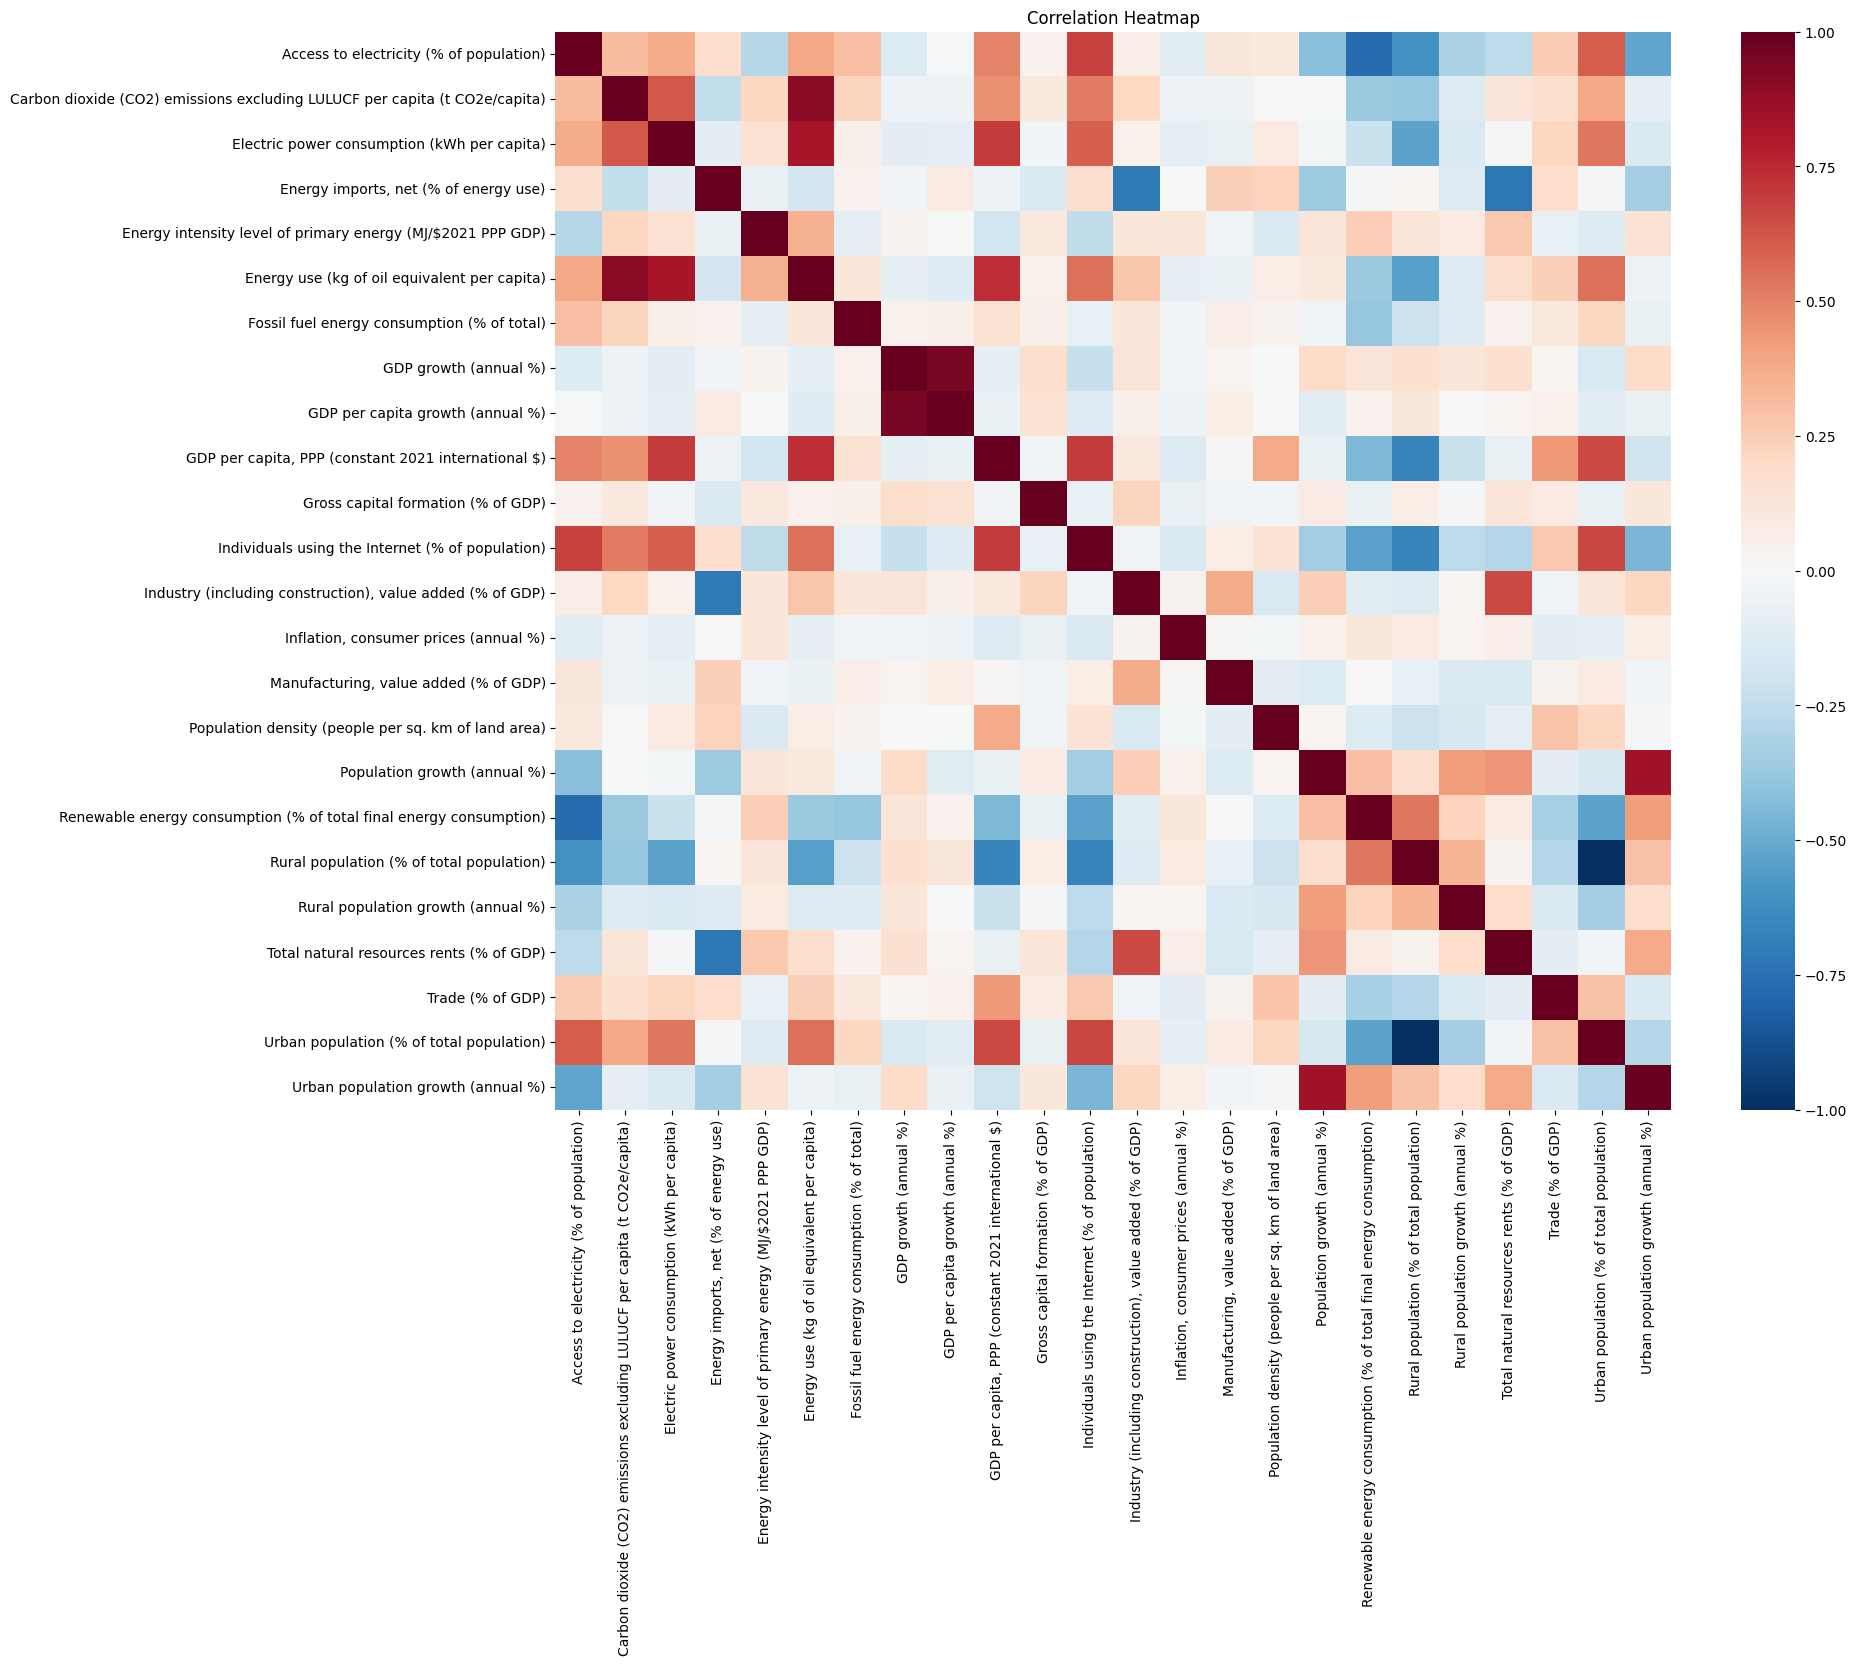

In [ ]:
# Heatmap of all variables
plt.figure(figsize=(18, 14))

sns.heatmap(corr_matrix,
            cmap="RdBu_r",  # We choose this color palette to distinguish the positive and negative values
            center=0,
            annot=False)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation Matrix - GDP vs. all numeric variables
gdp = "GDP per capita, PPP (constant 2021 international $)"

gdp_corr = (corr_matrix[gdp]
            .drop(gdp)
            .sort_values(ascending=False))  # Sort from largest to lowest

gdp_corr

,"GDP per capita, PPP (constant 2021 international $)"
Energy use (kg of oil equivalent per capita),0.735865
Individuals using the Internet (% of population),0.703111
Electric power consumption (kWh per capita),0.699756
Urban population (% of total population),0.662797
Access to electricity (% of population),0.492829
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),0.454350
Trade (% of GDP),0.429697
Population density (people per sq. km of land area),0.378809
Fossil fuel energy consumption (% of total),0.140930
"Industry (including construction), value added (% of GDP)",0.102258


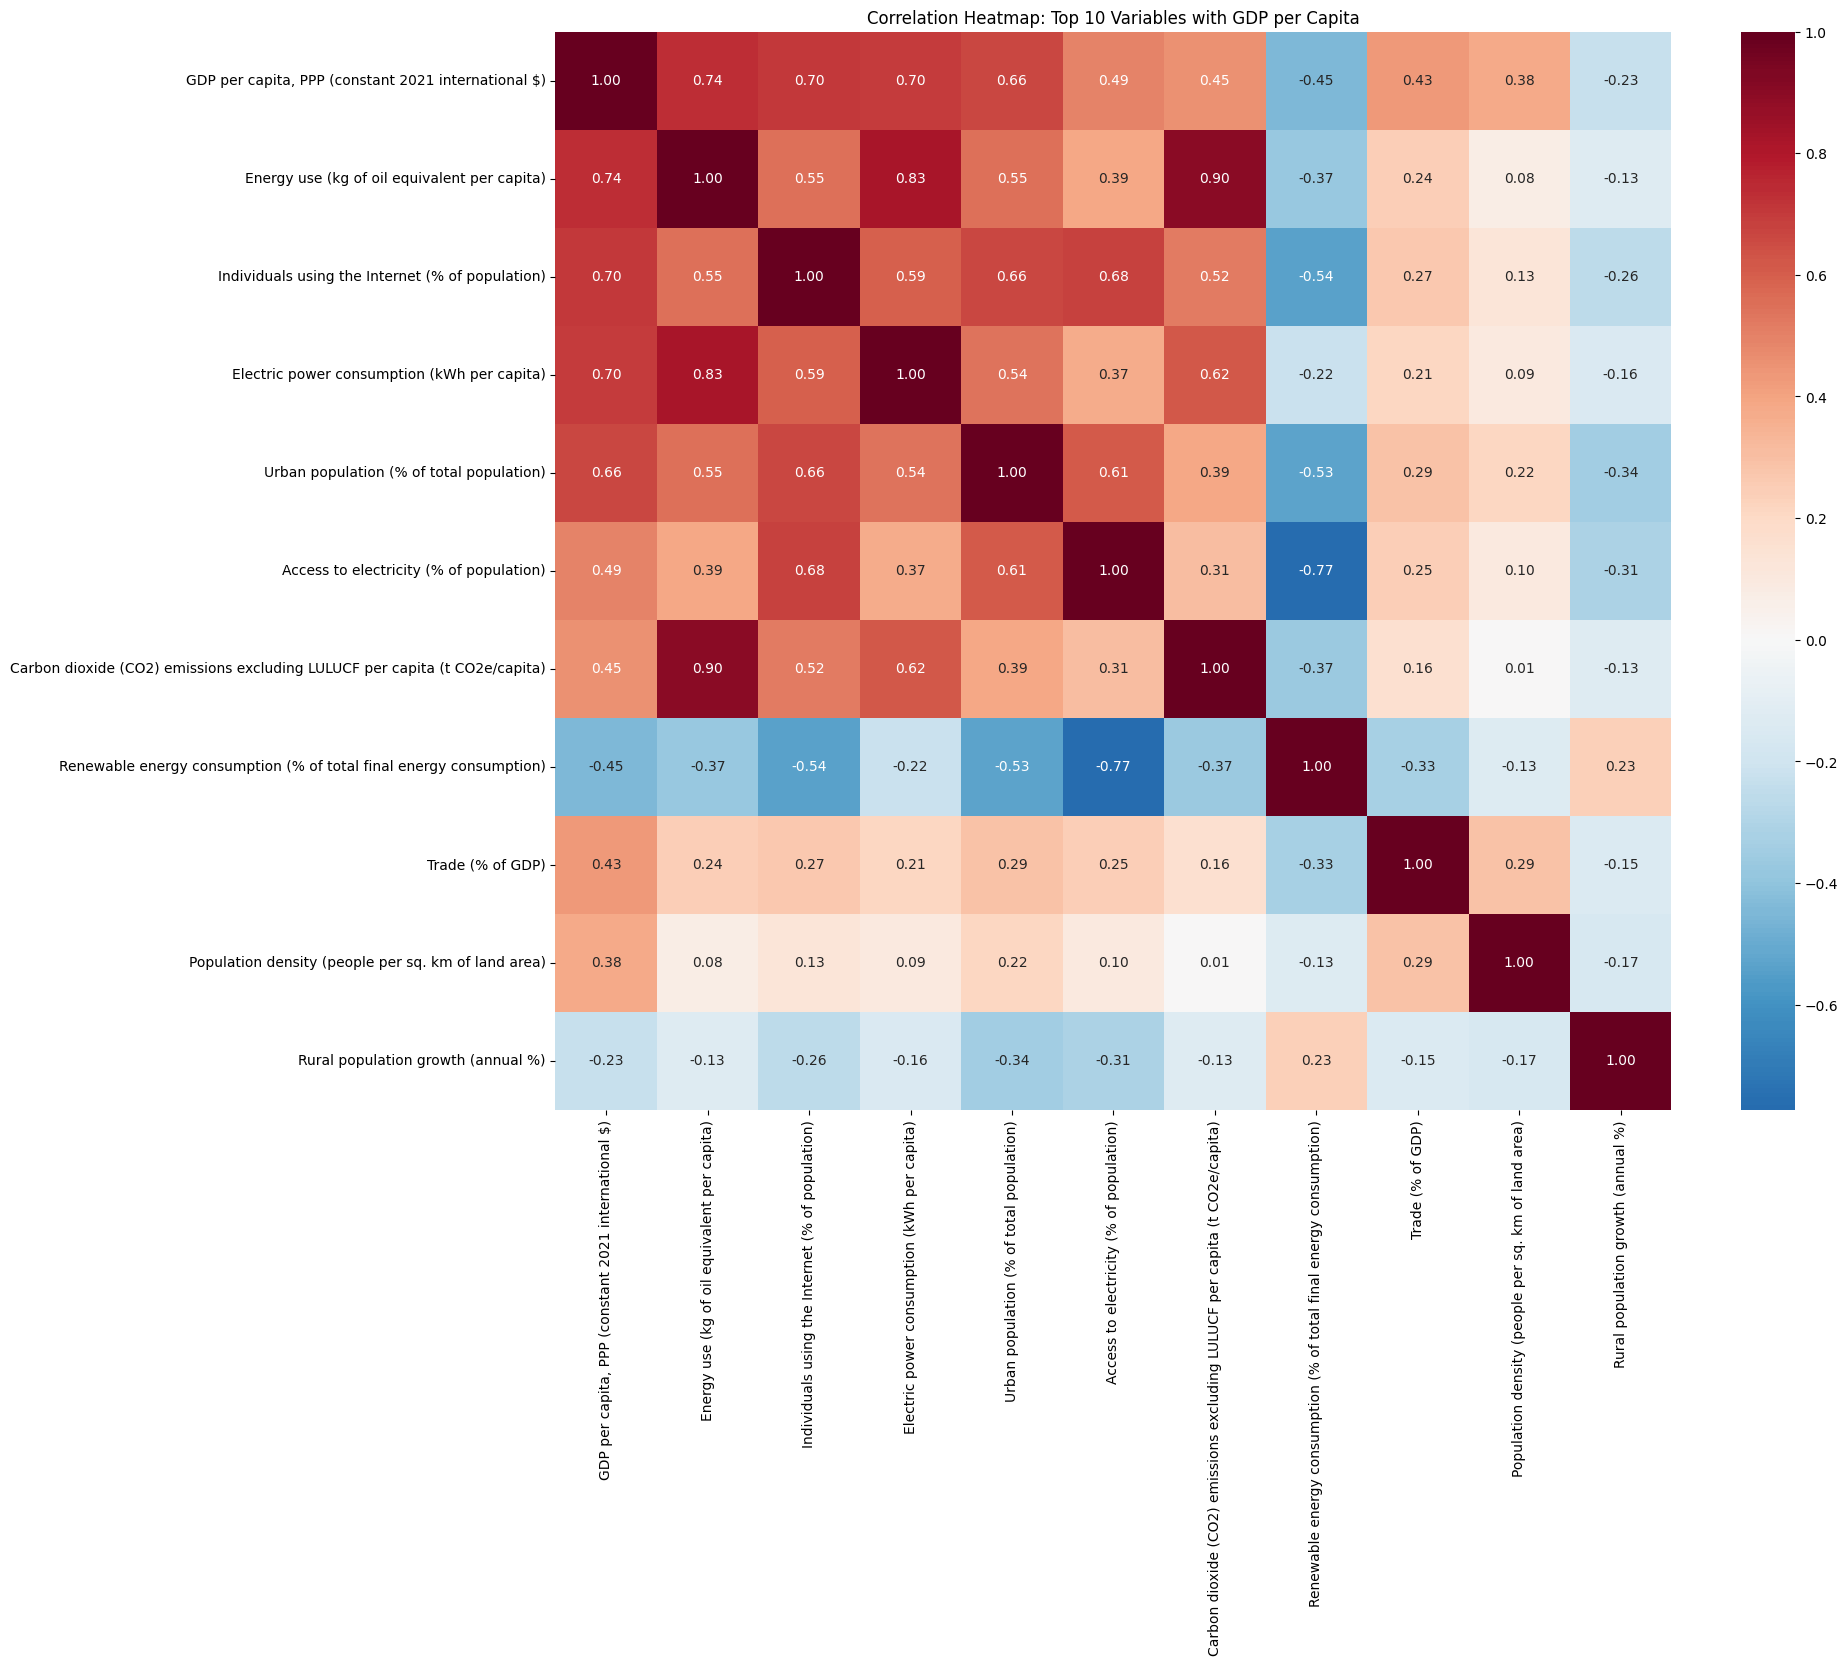

In [ ]:
# Heatmap of top 10 variables most strongly correlated with GDP based on absolute correlation
# Define top 10 variables based on absolute correlation with GDP
top_11 = (gdp_corr
          .abs()                              # We will use absolute values
          .sort_values(ascending=False)       # Sort highest to lowest
          .head(11)
          .index)                             # Only get the name, not the absolute values. We still use the original values later

# Remove Rural population because it is complementary to Urban population
top_10 = top_11.drop("Rural population (% of total population)")

# Add GDP
variables = [gdp] + list(top_10)

# Get the original correlation values of variables
top_corr = corr_matrix.loc[variables, variables]

# Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(top_corr,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0)

plt.title("Correlation Heatmap: Top 10 Variables with GDP per Capita")
plt.show()

**Q2: Choose one or two correlations and describe what the magnitude and direction of the correlation suggests about the relationship between the two variables.**

Based on the correlation martrix of all variables and heatmap of top 10 variables most strongly correlated with GDP based on absolute correlation above, it suggest that energy use per capital and percentage of individuals using the Internet


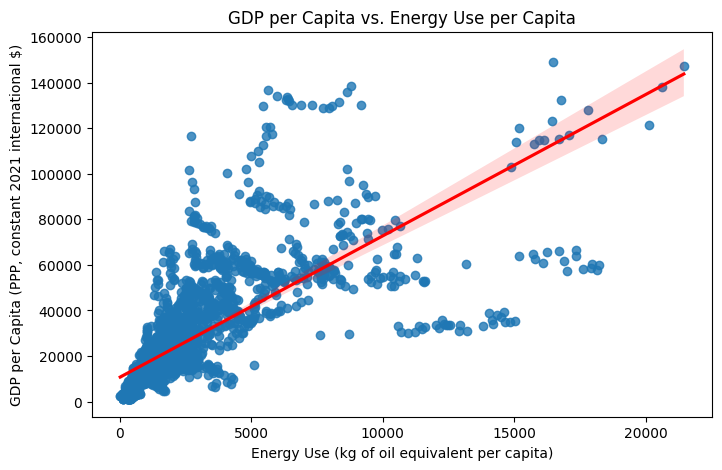

In [ ]:
#Scatter Plot: GDP per capital vs. Energy use per capital
plt.figure(figsize=(8, 5))

sns.regplot(data=df_final,
            x="Energy use (kg of oil equivalent per capita)",
            y=gdp,
            line_kws={"color": "red"})

plt.xlabel("Energy Use (kg of oil equivalent per capita)")
plt.ylabel("GDP per Capita (PPP, constant 2021 international $)")
plt.title("GDP per Capita vs. Energy Use per Capita")

plt.show()

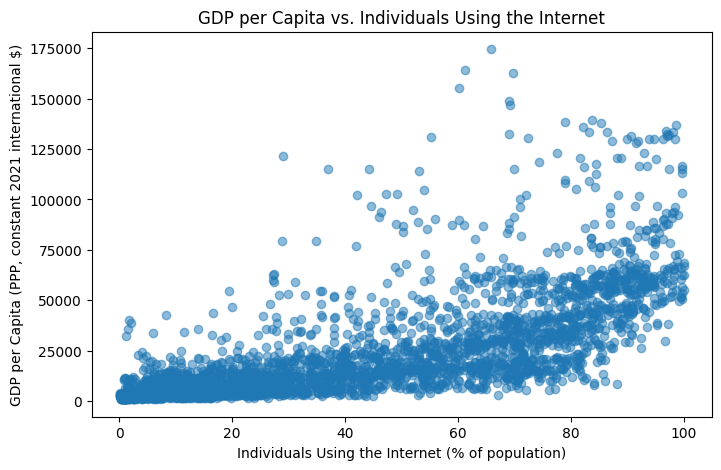

In [ ]:
#Scatter Plot: GDP per capital vs. % of individuals using the Internet
plt.figure(figsize=(8, 5))

plt.scatter(
    df_final['Individuals using the Internet (% of population)'],
    df_final[gdp],
    alpha=0.5
)

plt.xlabel("Individuals Using the Internet (% of population)")
plt.ylabel("GDP per Capita (PPP, constant 2021 international $)")
plt.title("GDP per Capita vs. Individuals Using the Internet")

plt.show()

# 5. Discussion: Did this exploritory data analysis help you better understand your chosen dataset? If so how? Is there still parts that don't make sense?
- Thoughtful discussion
of insights gained and
dataset limitations.
- Shows critical
engagement with EDA
process.